# Multiple Variable Linear Regression


## How to use this notebook

**Goal:** Connect housing data to multiple linear regression in NumPy: predictions, cost \(J(\mathbf{w}, b)\), gradients, and batch gradient descent.

**Before you start**
- Working through `linear_regression.ipynb` (single feature) first makes cost and gradient descent easier to follow.
- Run cells **from top to bottom** at least once so `df`, `X_train`, `y_train`, and `feature_cols` are defined.

**Learning path**
1. Build the design matrix vs the target vector.  
2. Prediction: explicit loop vs `np.dot`.  
3. Cost and partial derivatives (gradient).  
4. Optimize with gradient descent and read the cost curve.

**If something breaks:** Re-run from the imports cell after changing data paths, columns, or `\alpha`.


**Problem: Housing Price Prediction**

Dataset used: https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction?select=Housing.csv

This dataset provides key features for predicting house prices, including area, bedrooms, bathrooms, stories, amenities like air conditioning and parking, and information on furnishing status. It enables analysis and modelling to understand the factors impacting house prices and develop accurate predictions in real estate markets.

## Problem Statement

You will use the motivating example of housing price prediction. The training dataset contains examples with multiple features (like area, bedrooms, bathrooms and, stories) shown in the table below

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy, math

# Load the housing dataset
df = pd.read_csv('../../datasets/housing-price-prediction.csv')
target_col = "price"
feature_cols = ["area", "bedrooms", "bathrooms", "stories"]
df = df[feature_cols + [target_col]]
df.head()

,area,bedrooms,bathrooms,stories,price
0,7420,4,2,3,13300000
1,8960,4,4,4,12250000
2,9960,3,2,2,12250000
3,7500,4,2,2,12215000
4,7420,4,1,2,11410000


You will build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  

Please run the following code cell to create your `X_train` and `y_train` variables.

In [119]:
X_raw = df[feature_cols].to_numpy(dtype=float)
y_train = (df[target_col] / 1000).to_numpy()  # prices in thousands

# Z-score each feature so gradient descent does not diverge (area >> bedrooms, etc.)
X_mu = np.mean(X_raw, axis=0)
X_sigma = np.std(X_raw, axis=0)
X_train = (X_raw - X_mu) / X_sigma

print(f"X_train shape: {X_train.shape} (features are mean-0, std-1 per column)")
print(X_train[:3])
print(f"y_train shape: {y_train.shape}")
print(y_train[:8])

X_train shape: (545, 4) (features are mean-0, std-1 per column)
[[1.04672629 1.40341936 1.42181174 1.37821692]
 [1.75700953 1.40341936 5.40580863 2.53202371]
 [2.21823241 0.04727831 1.42181174 0.22441013]]
y_train shape: (545,)
[13300. 12250. 12250. 12215. 11410. 10850. 10150. 10150.]


### Design matrix vs target, and why we normalize

| | |
|---|---|
| **One row** | One house (one training example). |
| **`X_train`** | Only **inputs** (area, bedrooms, bathrooms, stories). Shape `(m, 4)`. |
| **`y_train`** | **Labels**: price in **thousands** to keep numbers moderate. Shape `(m,)`. |

**Z-score per column:** subtract the column mean and divide by the standard deviation. Then each feature has mean 0 and std 1 *in the training set*.

**Why it matters for gradient descent:** `area` is in the thousands; room counts are small. The partial derivatives multiply errors by `X[i, j]`, so raw `area` drives huge gradient components and unstable updates unless you shrink `\alpha` dramatically—or normalize so every feature contributes at a comparable scale.

**Inference later:** To predict for a **new** house, turn its raw features into z-scores with the **same** `X_mu` and `X_sigma` computed from training—then compute `np.dot(x_norm, w) + b`.


### Parameter vector w, b

* $\mathbf{w}$ is a vector with $n$ elements.
  - Each element contains the parameter associated with one feature.
  - in our dataset, n is 4.
  - notionally, we draw this as a column vector

$$\mathbf{w} = \begin{pmatrix}
w_0 \\ 
w_1 \\
\cdots\\
w_{n-1}
\end{pmatrix}
$$
* $b$ is a scalar parameter.

For demonstration, $\mathbf{w}$ and $b$ will be loaded with some initial selected values that are near the optimal. $\mathbf{w}$ is a 1-D NumPy vector.

In [120]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


## Model Prediction With Multiple Variables
The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$ 
where $\cdot$ is a vector `dot product`

To demonstrate the dot product, we will implement prediction using (1) and (2).

### Single Prediction element by element

Our previous prediction multiplied one feature value by one parameter and added a bias parameter. A direct extension of our previous implementation of prediction to multiple features would be to implement (1) above using loop over each element, performing the multiply with its parameter and then adding the bias parameter at the end.

In [121]:
def predict_single_loop(x, w, b): 
    """
    single predict using linear regression
    
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters    
      b (scalar):  model parameter     
      
    Returns:
      p (scalar):  prediction
    """
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]  
        p = p + p_i         
    p = p + b                
    return p

In [122]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [1.04672629 1.40341936 1.42181174 1.37821692]
f_wb shape (), prediction: 699.6275172990212


Note the shape of `x_vec`. It is a 1-D NumPy vector with 4 elements, (4,). The result, `f_wb` is a scalar.

### Single Prediction, vector

Noting that equation (1) above can be implemented using the dot product as in (2) above. We can make use of vector operations to speed up predictions.

Recall from the Python/Numpy lab that NumPy `np.dot()`[[link](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)] can be used to perform a vector dot product. 

In [123]:
def predict(x, w, b): 
    """
    single predict using linear regression
    Args:
      x (ndarray): Shape (n,) example with multiple features
      w (ndarray): Shape (n,) model parameters   
      b (scalar):             model parameter 
      
    Returns:
      p (scalar):  prediction
    """
    p = np.dot(x, w) + b     
    return p    

In [124]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [1.04672629 1.40341936 1.42181174 1.37821692]
f_wb shape (), prediction: 699.6275172990212


The results and shapes are the same as the previous version which used looping. Going forward, `np.dot` will be used for these operations. The prediction is now a single statement. Most routines will implement it directly rather than calling a separate predict routine.

## Compute Cost With Multiple Variables

The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$ 
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$ 


In contrast to previous labs, $\mathbf{w}$ and $\mathbf{x}^{(i)}$ are vectors rather than scalars supporting multiple features.

Below is an implementation of equations (3) and (4). Note that this uses a *standard pattern for this course* where a for loop over all `m` examples is used.

In [125]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar    
    return cost

In [126]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 9733396.922408346


**Note:** The `w_init` / `b_init` values come from the course example and are not fit to this CSV, so do not expect the cost to be ~0 at `w_init`. After z-score normalization, training should run without `inf` / `nan`.

## Gradient Descent With Multiple Variables

Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value

### Compute Gradient with Multiple Variables

An implementation for calculating the equations (6) and (7) is below. There are many ways to implement this. In this version, there is an
- outer loop over all m examples. 
    - $\frac{\partial J(\mathbf{w},b)}{\partial b}$ for the example can be computed directly and accumulated
    - in a second loop over all n features:
        - $\frac{\partial J(\mathbf{w},b)}{\partial w_j}$ is computed for each $w_j$.

In [127]:
def compute_gradient(X, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]   
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw

In [128]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -3981.548110907012
dj_dw at initial w,b: 
 [-1010.9527811   -696.81040098 -1022.03836668  -822.32538422]


**Note:** After z-score normalization, gradients are on the order of \(10^0\)–\(10^3\) for this dataset—not ~\(10^{-6}\)—unless `w`/`b` are near the optimum for your data.

In [129]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn w and b. Updates w and b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : initial model parameters  
      b_in (scalar)       : initial model parameter
      cost_function       : function to compute cost
      gradient_function   : function to compute the gradient
      alpha (float)       : Learning rate
      num_iters (int)     : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,)) : Updated values of parameters 
      b (scalar)       : Updated value of parameter 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")
        
    return w, b, J_history #return final w,b and J history for graphing

In [130]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 0.01  # use with z-score normalized X_train; raw features + large alpha cause overflow → nan
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 12850836.06   
Iteration  100: Cost 2355397.76   
Iteration  200: Cost 1018037.51   
Iteration  300: Cost 839208.03   
Iteration  400: Cost 814858.73   
Iteration  500: Cost 811468.31   
Iteration  600: Cost 810974.88   
Iteration  700: Cost 810896.70   
Iteration  800: Cost 810882.48   
Iteration  900: Cost 810879.42   
b,w found by gradient descent: 4766.52,[823.8483815  147.01475129 602.2646245  460.1773681 ] 
prediction: 7325.72, target value: 13300.0
prediction: 10841.26, target value: 12250.0
prediction: 7560.54, target value: 12250.0
prediction: 6825.16, target value: 12215.0
prediction: 5595.06, target value: 11410.0
prediction: 7294.55, target value: 10850.0
prediction: 9497.16, target value: 10150.0
prediction: 11530.05, target value: 10150.0
prediction: 5853.44, target value: 9870.0
prediction: 7022.74, target value: 9800.0
prediction: 7591.95, target value: 9800.0
prediction: 7454.91, target value: 9681.0
prediction: 6464.19, target value: 9310.0
predic

**Note:** Final `w`, `b`, and predictions depend on this CSV and hyperparameters (e.g. \(\alpha = 0.01\)), not the smaller course notebook dataset.

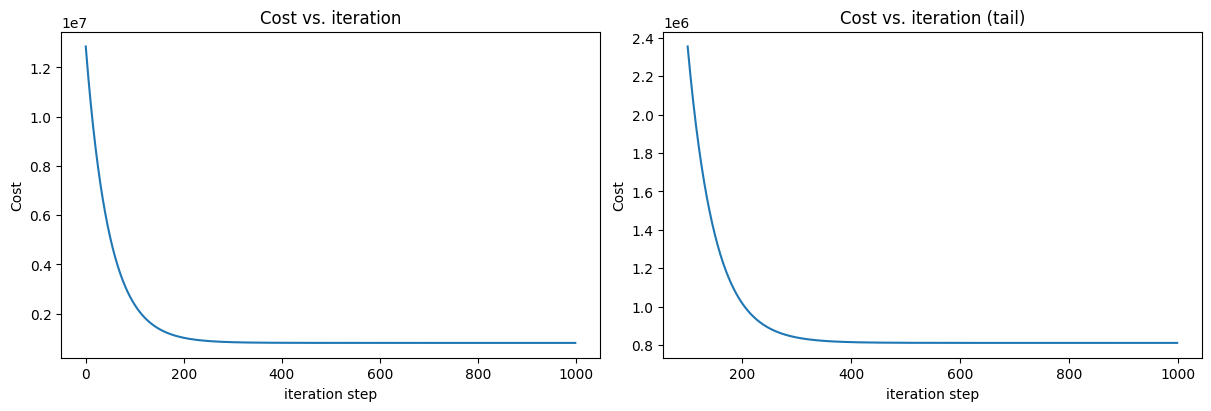

In [131]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

### Interpreting what you see

A **simple linear model** (`price` \(\approx\) linear combo of four features) cannot capture neighborhoods, renovations, market timing, etc., so errors will stay large vs a real pricing model.

Useful checks for learning:

- Does **cost decrease** early in training? If yes, gradient descent is doing its job on this formulation.  
- Plateau or noisy tail? Often `\alpha` is okay but the **model family** is too simple, or you need many more iterations / different features.  
- Compare this baseline to richer ideas later: polynomial terms, regularization, or other algorithms.

Treat the flat cost tail as motivation to study **feature engineering** and **model choice**, not as a bug in your NumPy code.
